In [1]:
EXP_NAME = "EXP_0_1"
MODEL_NAME = "GAN"

In [2]:
import torch; torch.manual_seed(0)
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from torch.utils.data import DataLoader
from function.Dir import Dir
from function.ssim_torch import ssim_function
from function.jsdiv import jsdiv 
from function.Dataset import ImageDataset
from function.Loss import Custom_criterion
from function.Log import log
import torch.nn.functional as F
import importlib

GAN_module = importlib.import_module(f'function.{MODEL_NAME}_{EXP_NAME}')
GAN = getattr(GAN_module, MODEL_NAME)

filepath = "/root/autodl-fs/norandPSF_6.4x6.4.npy"
NUM_TO_LEARN = 2400 #训练集放入图片对数量
NUM_TO_TEST = 400
EPOCHS = 200 #参数1
BATCH_SIZE = 32 #参数2
LATENTDIM = 64 #参数3
LR_MAX = 5e-4
LR_MIN = 5e-6
mode = 1 #0代表STED_HC文件训练，1代表使用STED，对应ImageDataset里的 mode 参数。（STED出的模型对泛化能力弱，STED_HC对训练集的还原会有点失真）

DEVICE = 'cuda'
LOSS_PLOT = []
TESTLOSS_PLOT = []
EPOCH_PLOT = []

print(f'Model successfully loaded: {MODEL_NAME}_{EXP_NAME}')

Model successfully loaded: GAN_EXP_0_1


In [5]:
from torchsummary import summary

# 实例化模型
model_test = GAN().to(DEVICE)  # 确保这里调用构造函数

# 输出模型结构
summary(model_test, input_size=(1, 64, 64))  # 根据输入的通道数和图像尺寸调整

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 64, 64]           5,248
            Conv2d-2           [-1, 32, 64, 64]          51,232
            Conv2d-3            [-1, 1, 64, 64]             801
         Generator-4            [-1, 1, 64, 64]               0
            Conv2d-5           [-1, 64, 32, 32]             640
            Conv2d-6          [-1, 128, 16, 16]          73,856
            Linear-7                    [-1, 1]          32,769
     Discriminator-8                    [-1, 1]               0
Total params: 164,546
Trainable params: 164,546
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.02
Forward/backward pass size (MB): 3.81
Params size (MB): 0.63
Estimated Total Size (MB): 4.46
----------------------------------------------------------------


In [9]:
name = f'{EPOCHS}epo_{BATCH_SIZE}bth_{LATENTDIM}latn'

#加载数据集
dataset = ImageDataset(NUM_TO_LEARN, mode,filepath)
testset = ImageDataset(NUM_TO_TEST,mode,filepath,inverse=True)
dataloader = DataLoader(dataset, BATCH_SIZE, True)
testloader = DataLoader(testset, BATCH_SIZE, True)

#初始化VAE网络
gan = GAN().to(DEVICE)
#vae.reset_parameters()
#vae = nn.DataParallel(vae) #将 VAE 包装成一个并行化模型，以便在多个 GPU 上并行地进行训练

#定义LOSS函数与优化器
#criterion1 = jsdiv#ssim_function#nn.MSELoss()
#criterion2 = jsdiv#ssim_function#Custom_criterion().cuda()
lossfunction = jsdiv
optimizer = torch.optim.AdamW(gan.parameters(), lr = LR_MAX)

In [ ]:
# 打印数据集中的一些样本
for batch_idx, (blurry_img, original_img) in enumerate(dataloader):
    continue
    print(f"Batch {batch_idx + 1}:")
    print(f"Blurry image shape: {blurry_img.shape}")
    print(f"Original image shape: {original_img.shape}")
blurry_img_numpy = blurry_img[1].squeeze().detach().numpy()
print(blurry_img_numpy.min())
print(blurry_img_numpy.max())
print(blurry_img_numpy)

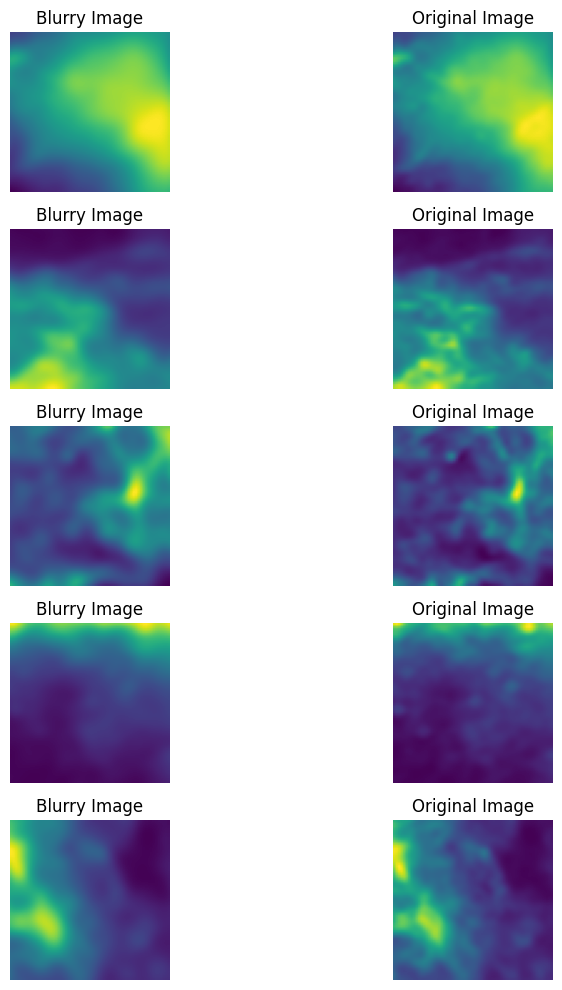

In [10]:
# 打印数据集中的一些样本
for batch_idx, (blurry_img, original_img) in enumerate(dataloader):
    continue
    print(f"Batch {batch_idx + 1}:")
    print(f"Blurry image shape: {blurry_img.shape}")
    print(f"Original image shape: {original_img.shape}")

num_images_to_show = 5
# 创建一个包含两列的图像网格，每一列显示一张模糊图像和一张原始图像
fig, axes = plt.subplots(num_images_to_show, 2, figsize=(10, 2*num_images_to_show))
# 遍历每个样本
for i in range(num_images_to_show):
    # 获取模糊图像和原始图像
    blurry_img_numpy = blurry_img[i].squeeze().detach().numpy()
    original_img_numpy = original_img[i].squeeze().detach().numpy()
    
    # 显示模糊图像
    axes[i, 0].imshow(blurry_img_numpy)
    axes[i, 0].set_title('Blurry Image')
    axes[i, 0].axis('off')
    
    # 显示原始图像
    axes[i, 1].imshow(original_img_numpy)
    axes[i, 1].set_title('Original Image')
    axes[i, 1].axis('off')

# 调整子图之间的间距
plt.tight_layout()

# 显示图像
plt.show()

In [11]:
def train(dataloader, num_epochs):
    with open(f'training.log', 'w') as nothing: # 清空原log
        pass
    log(f"Experiment name: {EXP_NAME}")
    for epoch in range(num_epochs):
        gan.train() # 切换成训练模式
        total_loss = 0.0
        current_lr = LR_MIN + 0.5 * (LR_MAX - LR_MIN) * (1 + np.cos(np.pi * epoch / EPOCHS))
        optimizer = torch.optim.AdamW(gan.parameters(), lr = current_lr)

        for _, (img_LR, img_HR) in enumerate(dataloader):
            # img_LR = torch.squeeze(img_LR,dim = 1).to(DEVICE)
            # img_HR = torch.squeeze(img_HR,dim = 1).to(DEVICE)
            img_LR = img_LR.to(DEVICE)
            img_HR = img_HR.to(DEVICE)
            img_SR, _ = gan(img_LR)
            img_SR = img_SR.to(DEVICE)
            # 这步为止，img_LR,img_HR,img_SR均是[batchsize,不知道是什么,宽，高]
            #if epoch <= 500:
            #    loss = criterion1(img_SR, img_HR)
            #if epoch > 500:
            #    loss = criterion2(img_SR, img_HR) # 每个BATCH的loss，64张图平均
            loss = lossfunction(img_SR,img_HR)
            optimizer.zero_grad()
            loss.backward() # 最耗算力的一步
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(dataloader) # 每个EPOCH的loss，全部数据集的平均

        test_loss = 0.0
        for _, (img_LR, img_HR) in enumerate(testloader):
            # img_LR = torch.squeeze(img_LR,dim = 1).to(DEVICE)
            # img_HR = torch.squeeze(img_HR,dim = 1).to(DEVICE)
            img_LR = img_LR.to(DEVICE)
            img_HR = img_HR.to(DEVICE)
            img_SR, _ = gan(img_LR)
            img_SR = img_SR.to(DEVICE)
            # 这步为止，img_LR,img_HR,img_SR均是[batchsize,不知道是什么,宽，高]
            #if epoch <= 500:
            #    loss = criterion1(img_SR, img_HR)
            #if epoch > 500:
            #    loss = criterion2(img_SR, img_HR) # 每个BATCH的loss，64张图平均
            loss = lossfunction(img_SR,img_HR)
            test_loss += loss.item()
        test_avg_loss = test_loss / len(testloader)

        
        print(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.6f}, Test Loss: {test_avg_loss:.6f}, Current_LR:{current_lr:.4f}")
        log(f"Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.6f}, Test Loss: {test_avg_loss:.6f}, Current_LR:{current_lr:.4f}")

        LOSS_PLOT.append(avg_loss)
        TESTLOSS_PLOT.append(test_avg_loss)
        EPOCH_PLOT.append(epoch)
        # if epoch % 300 == 0:
        #     torch.save(gan.state_dict(), Dir.TEMP()+'/checkpoint.pth')

In [ ]:
# for _, (img_LR, img_HR) in enumerate(dataloader):
#     img_SR, _, _ = vae(img_LR)
#     img_SR = img_SR.to(DEVICE)
#     print(img_SR.max())

In [12]:
datas = np.load(filepath,allow_pickle=True)#.astype(np.object)
blurry_datas = np.stack(datas[:,1])
original_datas = np.stack(datas[:,0])

In [ ]:
torch.set_printoptions(precision=10)
lossfunction = jsdiv
print(f'DEVICE:{DEVICE}\n')
print(f'Training Start. \nExperiment name: {EXP_NAME}')
train(dataloader, EPOCHS)
print(f'\n Succsessfully done! Training log saved.')

DEVICE:cuda

Training Start. 
Experiment name: EXP_0_1
Epoch [1/200], Average Loss: 0.002054, Test Loss: 0.000464, Current_LR:0.0005
Epoch [2/200], Average Loss: 0.000603, Test Loss: 0.000370, Current_LR:0.0005
Epoch [3/200], Average Loss: 0.000511, Test Loss: 0.000274, Current_LR:0.0005
Epoch [4/200], Average Loss: 0.000384, Test Loss: 0.000262, Current_LR:0.0005
Epoch [5/200], Average Loss: 0.000386, Test Loss: 0.000233, Current_LR:0.0005
Epoch [6/200], Average Loss: 0.000324, Test Loss: 0.000219, Current_LR:0.0005
Epoch [7/200], Average Loss: 0.000313, Test Loss: 0.000222, Current_LR:0.0005
Epoch [8/200], Average Loss: 0.000303, Test Loss: 0.000217, Current_LR:0.0005
Epoch [9/200], Average Loss: 0.000274, Test Loss: 0.000232, Current_LR:0.0005
Epoch [10/200], Average Loss: 0.000260, Test Loss: 0.000236, Current_LR:0.0005
Epoch [11/200], Average Loss: 0.000253, Test Loss: 0.000184, Current_LR:0.0005
Epoch [12/200], Average Loss: 0.000276, Test Loss: 0.000191, Current_LR:0.0005
Epoch 

In [ ]:
fig,ax = plt.subplots()
ax.plot(EPOCH_PLOT,LOSS_PLOT)
ax.plot(EPOCH_PLOT,TESTLOSS_PLOT)
fig.savefig(f'../models/{EXP_NAME}_lossfig_{name}.png', dpi = 300) # 保存LOSS图片
print(f'LOSS fig saved at {Dir.models()}/{EXP_NAME}_lossfig_{name}.png')
LOSS_DATA = np.stack((np.array(EPOCH_PLOT),np.array(LOSS_PLOT)),axis=0)
np.save(f'../models/{EXP_NAME}_lossdata_{name}.npy',LOSS_DATA) # 保存LOSS数据
print(f'LOSS data saved at {Dir.models()}/{EXP_NAME}_lossdata_{name}.npy')
torch.save(vae.state_dict(), f'../models/{EXP_NAME}_model_{name}.pth') #保存模型pth
print(f'MODEL saved at {Dir.models()}/{EXP_NAME}_model_{name}.pth')

In [ ]:
'''import matplotlib.pyplot as plt
import torchvision.utils as vutils

def visualize_vae_effect(vae, dataloader, num_images, device):
    vae.eval()  # 切换到评估模式
    data_iter = iter(dataloader)
    
    # 获取一些图像
    img_LR, img_HR = next(data_iter)
    img_LR = img_LR.to(device)
    img_HR = img_HR.to(device)
    
    with torch.no_grad():
        img_SR, _, _ = vae(img_LR)
    
    # 移动到CPU并转换为numpy数组以进行可视化
    img_LR = img_LR.cpu()
    img_SR = img_SR.cpu()
    img_HR = img_HR.cpu()
    
    
    # 绘制图像
    #fig, axes = plt.subplots(3, 1, figsize=(15, 15))
    fig, axes = plt.subplots(1, 1, figsize=(15, 15))
    axes[0].imshow(img_LR[0,0])
    axes[0].set_title('Input Images (LR)')
    axes[0].axis('off')
    
    #axes[1].imshow(output_grid.permute(1, 2, 0).numpy())
    #axes[1].set_title('Reconstructed Images (SR)')
    #axes[1].axis('off')
    
    #axes[2].imshow(real_grid.permute(1, 2, 0).numpy())
    #axes[2].set_title('Real High-Resolution Images (HR)')
    #axes[2].axis('off')
    
    plt.show()

# 在训练结束后调用该函数
visualize_vae_effect(vae, dataloader, num_images=8, device=DEVICE)'''


In [ ]:
import torch
import matplotlib.pyplot as plt

vae.eval()  # 切换到评估模式

for _, (img_LR, img_HR) in enumerate(testloader):
    #print(img_LR.shape)
    img_SR, _, _ = vae(img_LR.to('cuda'))
    img_SR = img_SR.cpu()

num_images_to_show = 5
# 创建一个包含三列的图像网格，每一列显示一张模糊图像、超分辨率图像和原始图像
fig, axes = plt.subplots(num_images_to_show, 3, figsize=(15, 3 * num_images_to_show))

# 遍历每个样本
for i in range(num_images_to_show):
    # 获取模糊图像、超分辨率图像和原始图像
    blurry_img_numpy = img_LR[i].squeeze().detach().cpu().numpy()
    sr_img_numpy = img_SR[i].squeeze().detach().cpu().numpy()
    original_img_numpy = img_HR[i].squeeze().detach().cpu().numpy()
    
    # 显示模糊图像
    axes[i, 0].imshow(blurry_img_numpy)
    axes[i, 0].set_title('Blurry Image')
    axes[i, 0].axis('off')

    # 显示超分辨率图像
    axes[i, 1].imshow(sr_img_numpy)
    axes[i, 1].set_title('SR Image')
    axes[i, 1].axis('off')
    
    # 显示原始图像
    axes[i, 2].imshow(original_img_numpy)
    axes[i, 2].set_title('Original Image')
    axes[i, 2].axis('off')

# 调整子图之间的间距
plt.tight_layout()

# 显示图像
plt.show()
